# Implement a program to build a spam filter using Natural Language Processing (NLP)

In [3]:
import kagglehub
karthickveerakumar_spam_filter_path = kagglehub.dataset_download('karthickveerakumar/spam-filter')

print('Data source import complete.')


Using Colab cache for faster access to the 'spam-filter' dataset.
Data source import complete.


In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [7]:
for dirname, _, filenames in os.walk(karthickveerakumar_spam_filter_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/spam-filter/emails.csv


In [9]:
# Step 3: Load Dataset
df = pd.read_csv(os.path.join(karthickveerakumar_spam_filter_path, 'emails.csv'))
print("\n Dataset loaded successfully!")
print(df.head())

print("\nShape of dataset:", df.shape)
df.info()


 Dataset loaded successfully!
                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1

Shape of dataset: (5728, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [11]:
#  Check for Missing Values
print("\nMissing Values:\n", df.isna().sum())


Missing Values:
 text    0
spam    0
dtype: int64



Spam value counts:
 spam
0    4360
1    1368
Name: count, dtype: int64


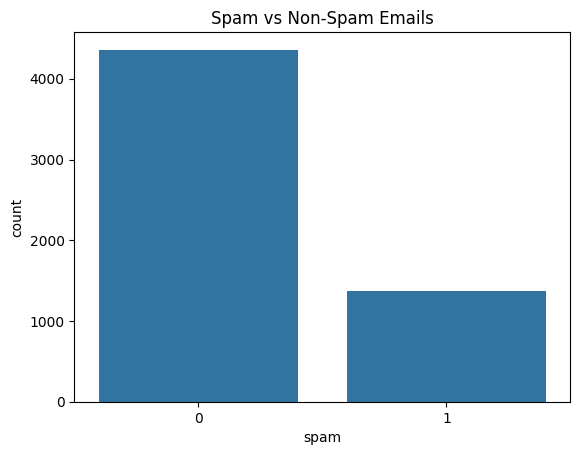

In [12]:
# Step 4: Exploratory Data Analysis
print("\nSpam value counts:\n", df['spam'].value_counts())
sns.countplot(x='spam', data=df)
plt.title("Spam vs Non-Spam Emails")
plt.show()

In [15]:
# Step 5: Check relation between email length & spam
from nltk import word_tokenize
import nltk
nltk.download('punkt')  # Required for tokenization
nltk.download('punkt_tab') # Required for PunktTokenizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [16]:
# Function to count words in email text
def count_words(text):
    words = word_tokenize(text)
    return len(words)

df['count'] = df['text'].apply(count_words)
print("\nAverage word count by spam type:\n", df.groupby('spam')['count'].mean())


Average word count by spam type:
 spam
0    346.835321
1    267.896199
Name: count, dtype: float64


In [17]:
#  Step 6: Text Preprocessing
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

def process_text(text):
    # Remove punctuation
    no_punc = ''.join([char for char in text if char not in string.punctuation])
    # Remove stopwords
    cleaned = ' '.join([word for word in no_punc.split() if word.lower() not in stopwords.words('english')])
    return cleaned

df['text'] = df['text'].apply(process_text)
print("\n Text cleaned successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



 Text cleaned successfully!


In [18]:
#  Step 7: Stemming
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def stemming(text):
    words = [stemmer.stem(word) for word in text.split()]
    return ' '.join(words)

df['text'] = df['text'].apply(stemming)
print("\n Stemming completed!")


 Stemming completed!


In [19]:
print(df.head())

                                                text  spam  count
0  subject natur irresist corpor ident lt realli ...     1    325
1  subject stock trade gunsling fanni merril muzo...     1     90
2  subject unbeliev new home made easi im want sh...     1     88
3  subject 4 color print special request addit in...     1     99
4  subject money get softwar cd softwar compat gr...     1     53


In [20]:
#  Step 8: Bag of Words Model
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
message_bow = vectorizer.fit_transform(df['text'])
print("\n Bag of Words created. Vocabulary size:", len(vectorizer.get_feature_names_out()))


 Bag of Words created. Vocabulary size: 29254


In [21]:
#  Step 9: Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(message_bow, df['spam'], test_size=0.2, random_state=42)
print("\n Data split into training and testing sets.")


 Data split into training and testing sets.


In [22]:
#  Step 10: Train Naive Bayes Model
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()


📋 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       856
           1       0.97      0.99      0.98       290

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146



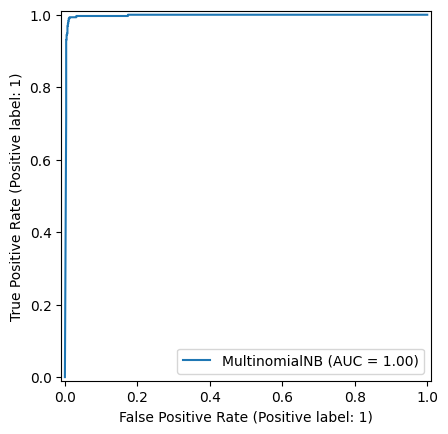

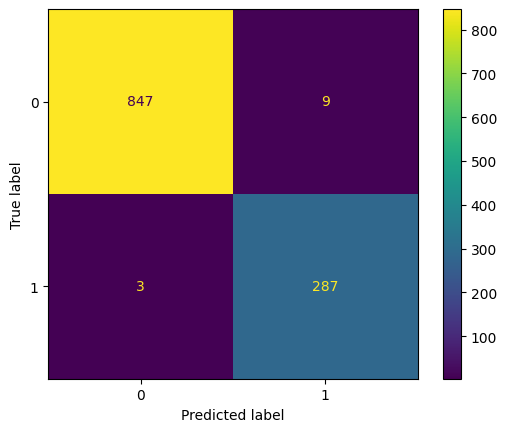

In [24]:
#  Step 11: Model Evaluation
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay

y_pred = nb.predict(X_test)
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

RocCurveDisplay.from_estimator(nb, X_test, y_test)
plt.show()

ConfusionMatrixDisplay.from_estimator(nb, X_test, y_test)
plt.show()

In [25]:
#  Step 12: Cross-Validation
from sklearn.model_selection import KFold, cross_val_score
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_score = np.mean(cross_val_score(nb, message_bow, df['spam'], cv=kfold, scoring="accuracy")) * 100
print(f"\n Accuracy using Cross Validation: {cv_score:.2f} %")


 Accuracy using Cross Validation: 98.92 %


In [26]:
#  Step 13: Spam Prediction Function
def predict_spam(email_text):
    # Transform the input text
    email_features = vectorizer.transform([email_text])
    # Predict
    prediction = nb.predict(email_features)
    return "Spam" if prediction[0] == 1 else "Not Spam"

#  Test Example
new_email = "Congratulations! You won a free lottery ticket. Call now!"
result = predict_spam(new_email)
print(f"\n Example Email: {new_email}")
print(f" The email is classified as: {result}")


 Example Email: Congratulations! You won a free lottery ticket. Call now!
 The email is classified as: Not Spam
